# Notebook di test

In [7]:

import numpy as np
from scipy import linalg  # Per l'algebra lineare (autovalori, autovettori)
import utils.lib.nn_studio as nn_studio
import utils.lib.chiral_potential as chiral_potential
import matplotlib.pyplot as plt
import utils.lib.granada_phases as granada
import utils.lib.auxiliary as aux
import utils.lib.lec_values as lec_values
import utils.lib.auxiliary as aux

from scipy.optimize import least_squares

In [2]:
%matplotlib widget
plt.close('all')

computing T-matrices for
channel = [{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]
Tlab = 1e-06 MeV
Tlab = 0.1 MeV
Tlab = 0.2 MeV
Tlab = 0.3 MeV
Tlab = 0.4 MeV
Tlab = 0.5 MeV
Tlab = 0.6 MeV
Tlab = 0.7 MeV
Tlab = 0.8 MeV
Tlab = 0.9 MeV
Tlab = 1.0 MeV
Tlab = 2 MeV
Tlab = 3 MeV
Tlab = 4 MeV
Tlab = 5 MeV
Tlab = 6 MeV
Tlab = 7 MeV
Tlab = 8 MeV
Tlab = 9 MeV
Tlab = 10 MeV
Tlab = 11 MeV
Tlab = 12 MeV
Tlab = 13 MeV
Tlab = 14 MeV
Tlab = 15 MeV
Tlab = 16 MeV
Tlab = 17 MeV
Tlab = 18 MeV
Tlab = 19 MeV
Tlab = 20 MeV
Tlab = 21 MeV
Tlab = 22 MeV
Tlab = 23 MeV
Tlab = 24 MeV
Tlab = 25 MeV
Tlab = 26 MeV
Tlab = 27 MeV
Tlab = 28 MeV
Tlab = 29 MeV
Tlab = 30 MeV
Tlab = 40 MeV
Tlab = 50 MeV
Tlab = 60 MeV
Tlab = 70 MeV
Tlab = 80 MeV
Tlab = 90 MeV
Tlab = 100 MeV


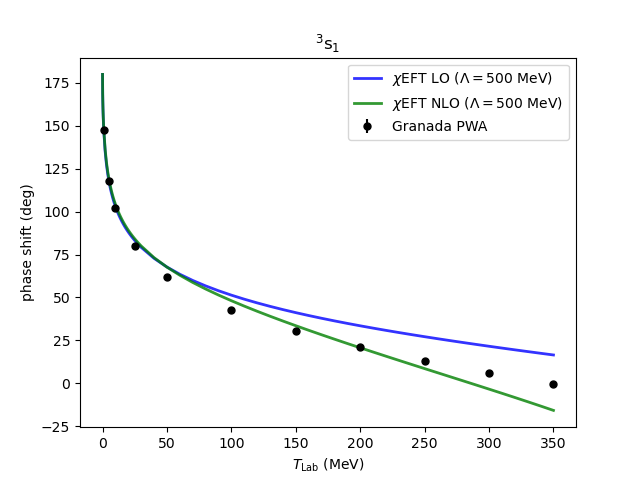

In [3]:


# initialize an object for computing T-matrices, phase shifts
# Np is the number of quadrature points used in the solution of the LS equation.
# the mesh_type defaults to 'gauleg_infinite' if nothing else. Use this for scattering.
# (use gauleg_finite for bound states).
nn = nn_studio.nn_studio(jmin=0,jmax=1,tzmin=0,tzmax=0,Np=30)

# define the lab neutron-proton kinetic energies that you want to analyze (denser for low T in this case)
nn.Tlabs = [1e-6] + [x/10 for x in np.arange(1,11,1)]+[x for x in np.arange(2,31,1)] + [x for x in np.arange(40,360,10)]
## you can inspect results for the channels <ll s j || l s j> in your basis
_,selected_channel = nn.lookup_channel_idx(l=0,ll=2,s=1,j=1)

#get the 'empirical' granada values for plotting
exp_phases = granada.delta_3S1
err_phases = granada.delta_3S1_errors

# initialize an object for the chiral interaction (isospin symmetric LO, NLO in WPC available)
potential_lo = chiral_potential.two_nucleon_potential('LO',Lambda=500.0)
potential_nlo = chiral_potential.two_nucleon_potential('NLO',Lambda=500.0)

# give the potential to the nn-analyzer
nn.V = potential_lo
# give the LECS to the potential (via the nn-analyzer)
nn.lecs = lec_values.lo_lecs
# solve the Lippmann-Schwinger equation and compute phase shifts (for selected_channel)
nn.compute_Tmtx(selected_channel,verbose=True)
delta_lo = nn.phase_shifts[0][:,0]

#now solve for NLO
nn.V = potential_nlo
nn.lecs = lec_values.nlo_lecs
nn.compute_Tmtx(selected_channel,verbose=True)
delta_nlo = nn.phase_shifts[0][:,0]

# plot the result
plt.errorbar(granada.Tlabs,exp_phases, yerr=err_phases,label = 'Granada PWA', color='black',ls='none',marker='o',markersize=5.)
plt.plot(nn.Tlabs,delta_lo, label = r'$\chi$EFT LO ($\Lambda=500$ MeV)',color='blue',alpha=0.8,lw=2)
plt.plot(nn.Tlabs,delta_nlo, label = r'$\chi$EFT NLO ($\Lambda=500$ MeV)',color='green',alpha=0.8,lw=2)
plt.xlabel(r'$T_\mathrm{Lab}$ (MeV)')
plt.ylabel(r'phase shift (deg)')
plt.title(r'$^3$s$_1$')
plt.legend()
#plt.savefig('lo_nlo_phases.pdf')
plt.show()





In [ ]:
# Inizializza un oggetto per il calcolo delle matrici T e delle fasi di scattering
nn = nn_studio.nn_studio(jmin=0, jmax=1, tzmin=0, tzmax=0, Np=130, mesh_type='gauleg_finite')


# Inizializza il potenziale chirale a Leading Order (LO) con cutoff Lambda=500 MeV
potential = chiral_potential.two_nucleon_potential('LO', Lambda=500.0)


# Assegna il potenziale all'oggetto nn (analizzatore nucleone-nucleone)
nn.V = potential


# Assegna i valori delle costanti di accoppiamento a bassa energia (LECs) al potenziale tramite nn
input_lecs = lec_values.lo_lecs
nn.lecs = input_lecs.copy()


# Il canale del deuterone è un tripletto accoppiato e consiste in quattro possibili combinazioni di l (momento angolare orbitale)
# e ll (momento angolare orbitale accoppiato): S-S, S-D, D-S, D-D. La funzione lookup_channel_idx cerca il canale corretto
# dato l, ll, s (spin totale) e j (momento angolare totale). Restituisce il canale del deuterone se i parametri corrispondono.
_, deuteron_channel = nn.lookup_channel_idx(l=0, ll=2, s=1, j=1)
print(deuteron_channel)  # Stampa le informazioni sul canale deuterone trovato


# Calcola la massa ridotta (mu) per il sistema nucleone-nucleone
_, mu = nn.lab2rel(0, 0)


# Numero totale di punti di mesh (Np per ciascun blocco, 2 blocchi)
N = 2 * (nn.Np)


# Inizializza le matrici Hamiltoniana (H) e cinetica (T)
H = np.zeros((N, N))
T = np.zeros((N, N))


# Unisce i pesi e i punti di mesh per i due blocchi
ww = np.hstack((nn.wmesh, nn.wmesh))
pp = np.hstack((nn.pmesh, nn.pmesh))


# Costruisce la matrice del potenziale per il canale deuterone
V = nn.setup_Vmtx(deuteron_channel[0])[0]


# Costruisce le matrici T (cinetica) e V (potenziale) e l'Hamiltoniana totale H = T + V
for i, p_bra in enumerate(pp):
    for j, p_ket in enumerate(pp):
        Tij = 0
        # Solo i termini diagonali della matrice T sono diversi da zero
        if i == j:
            Tij = p_bra ** 2 / (2 * mu)
            T[i][j] = Tij
        # Normalizza il potenziale con i pesi di quadratura e i momenti
        V[i][j] = V[i][j] * p_bra * p_ket * np.sqrt(ww[i] * ww[j])

# Somma le matrici per ottenere l'Hamiltoniana totale
H = T + V


# Calcola autovalori e autovettori dell'Hamiltoniana (soluzione dell'equazione di Schrödinger)
eigvals, eigvecs = linalg.eigh(H)
s = np.argsort(eigvals)  # Ordina gli autovalori
E = eigvals[s[0]]  # Prende il più basso (stato fondamentale, energia del deuterone)

# Autovettore corrispondente all'autovalore più basso (funzione d'onda del deuterone)
psi_k = eigvecs[:, s[0]]

# Stampa l'energia del deuterone trovata
print(f'E = {E}')

# Normalizzare la funzione d'onda e calcolare le probabilità delle componenti S e D
# L'autovettore psi_k è diviso in due blocchi:
# I primi Np elementi sono l'onda S (L=0)
# I secondi Np elementi sono l'onda D (L=2)

u_tilde = psi_k[:nn.Np]  # Componente S
w_tilde = psi_k[nn.Np:]  # Componente D

# La probabilità è semplicemente la somma dei quadrati
P_S = np.sum(u_tilde**2)
P_D = np.sum(w_tilde**2)

print(f"Probabilità onda S (P_S): {P_S * 100:.2f}%")
print(f"Probabilità onda D (P_D): {P_D * 100:.2f}%")
#print(f"Normalizzazione totale: {(P_S + P_D) * 100:.2f}%")

[[{'l': 0, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 0, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 0, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}, {'l': 2, 'll': 2, 's': 1, 'j': 1, 't': 0, 'tz': 0, 'pi': 1, 'chn_idx': 4}]]
E = -1.9276646268274813
Probabilità onda S (P_S): 92.12%
Probabilità onda D (P_D): 7.88%
Normalizzazione totale: 100.00%
